# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [3]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.


# **Loading the dataset**

In [4]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('EasyVisa.csv')



# **Overview of the Dataset**

* Observations

* Sanity checks

In [5]:
# Checking the first and last few rows
display(df.head())
display(df.tail())

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [6]:
df.shape

(25480, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
# Checking for duplicate entries
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

Number of duplicate rows: 0


In [9]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
display(missing_values)

Missing values in each column:


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


# **Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

In [10]:
# Summary statistics for all columns
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Drop unnecessary column
df.drop(columns=['case_id'], inplace=True)
list(df.columns)

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'no_of_employees',
 'yr_of_estab',
 'region_of_employment',
 'prevailing_wage',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [12]:
df.loc[df["no_of_employees"] < 0].shape

(33, 11)

In [13]:
df.loc[df["no_of_employees"] < 0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [14]:
# Remove negative employees as the rows are just 33 out of total 25k
df = df[df['no_of_employees'] > 0]



In [15]:
df.shape

(25447, 11)

In [16]:
cat_col = list(df.select_dtypes("object").columns)

for column in cat_col:
    print(df[column].value_counts())
    print("-"*50)

continent
Asia             16840
Europe            3727
North America     3287
South America      851
Africa             550
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10220
Master's        9622
High School     3416
Doctorate       2189
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14786
N    10661
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22498
Y     2949
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7189
South        7006
West         6578
Midwest      4299
Island        375
Name: count, dtype: int64
--------------------------------------------------
unit_of_wage
Year     22933
Hour      2153
Week       272
Month       89
Name: count, dtype: int64
--------------------------------------------------
full_time_posit

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Univariate Analysis

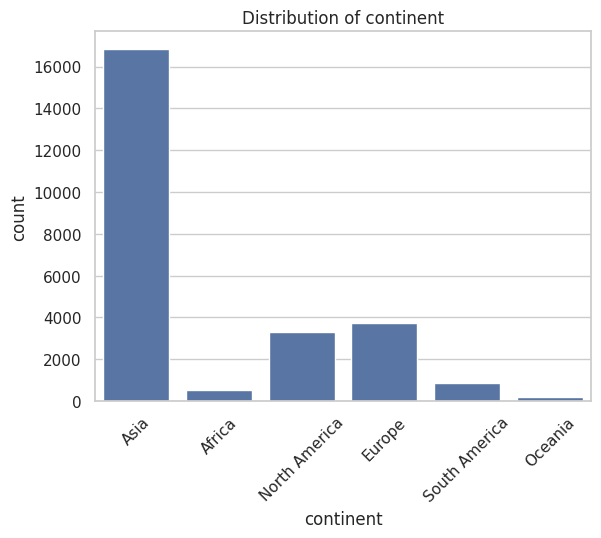

continent
Asia             0.661768
Europe           0.146461
North America    0.129170
South America    0.033442
Africa           0.021614
Oceania          0.007545
Name: proportion, dtype: float64




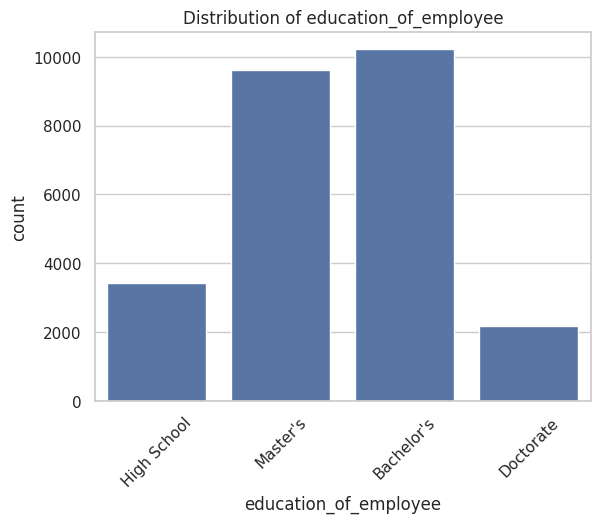

education_of_employee
Bachelor's     0.401619
Master's       0.378119
High School    0.134240
Doctorate      0.086022
Name: proportion, dtype: float64




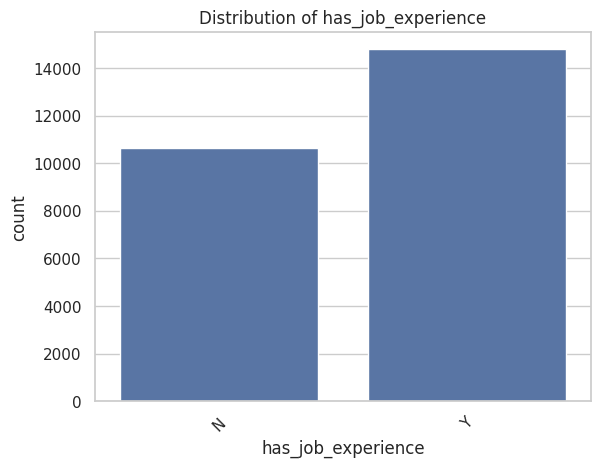

has_job_experience
Y    0.581051
N    0.418949
Name: proportion, dtype: float64




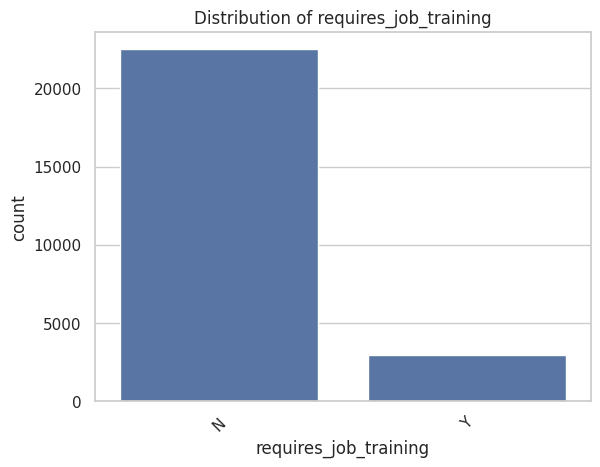

requires_job_training
N    0.884112
Y    0.115888
Name: proportion, dtype: float64




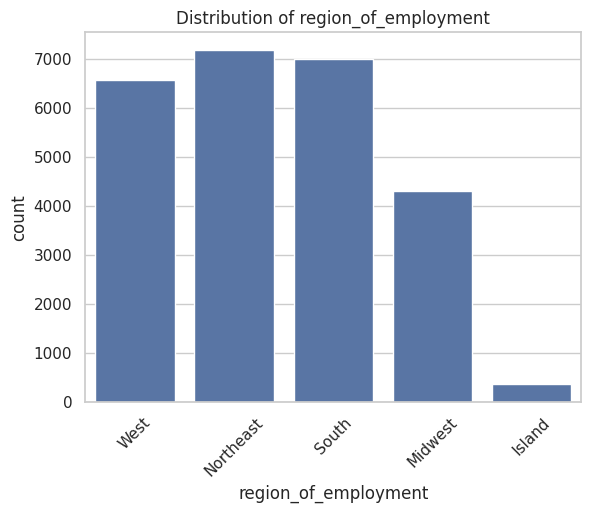

region_of_employment
Northeast    0.282509
South        0.275317
West         0.258498
Midwest      0.168939
Island       0.014737
Name: proportion, dtype: float64




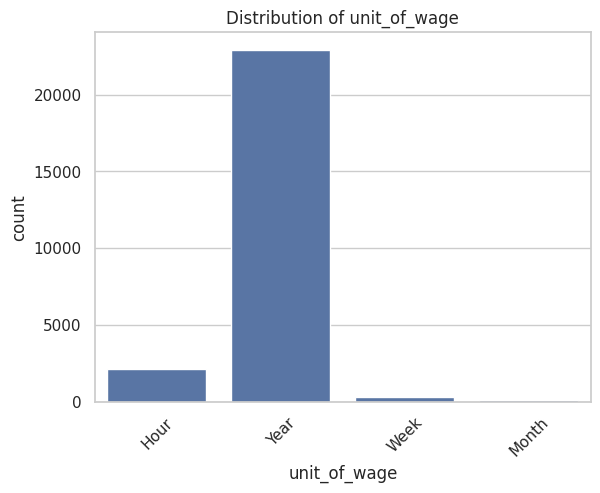

unit_of_wage
Year     0.901206
Hour     0.084607
Week     0.010689
Month    0.003497
Name: proportion, dtype: float64




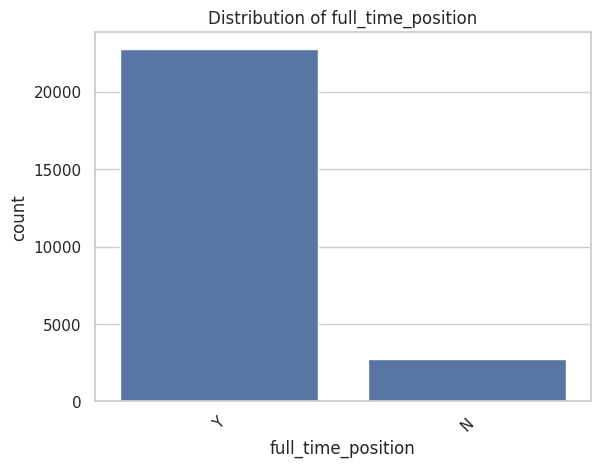

full_time_position
Y    0.893661
N    0.106339
Name: proportion, dtype: float64




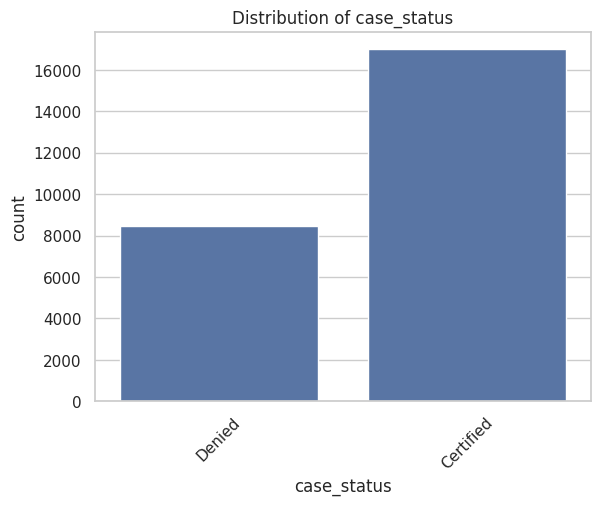

case_status
Certified    0.668094
Denied       0.331906
Name: proportion, dtype: float64




In [18]:
cat_cols = list(df.select_dtypes("object").columns)
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

    print(df[col].value_counts(normalize=True))
    print("\n")

In [19]:
# Selecting all numerical columns (integers and floats)
num_cols = list(df.select_dtypes(include=np.number).columns)
print(f"Numerical columns: {num_cols}")

Numerical columns: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


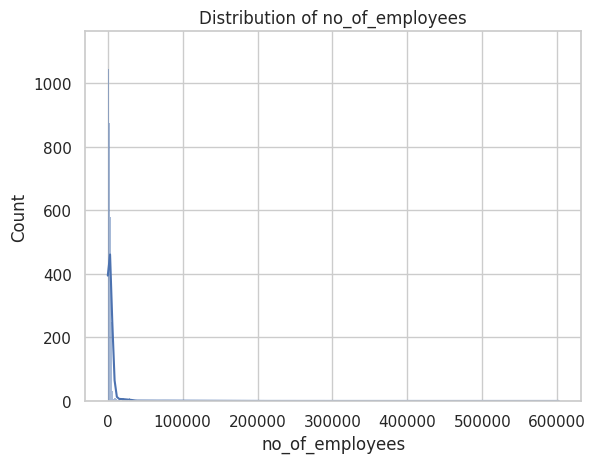

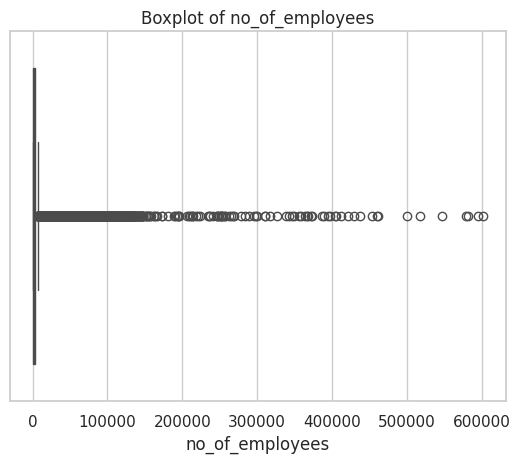

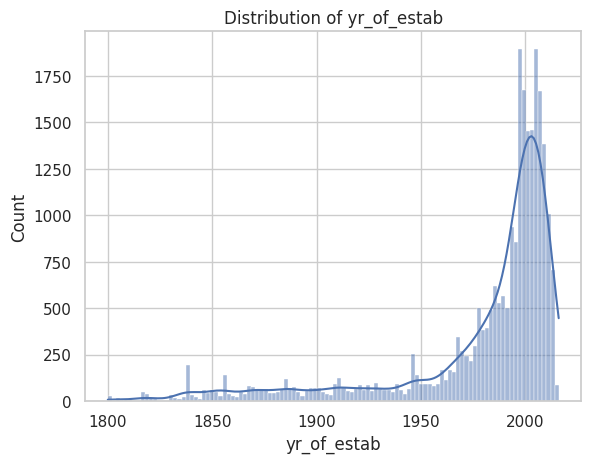

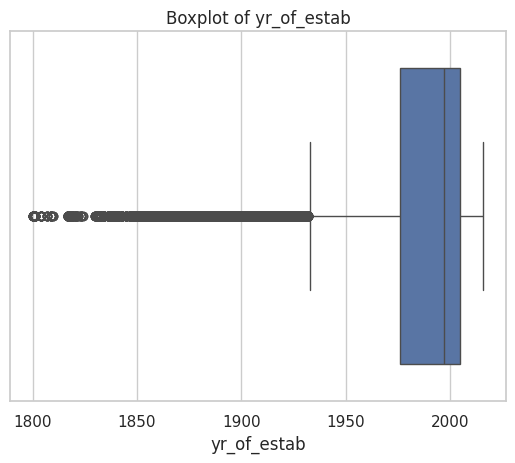

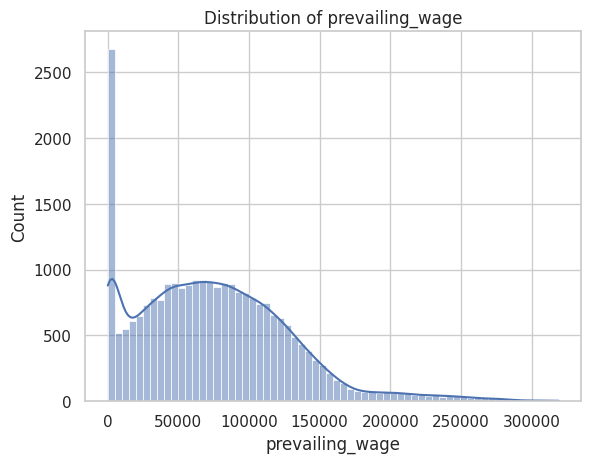

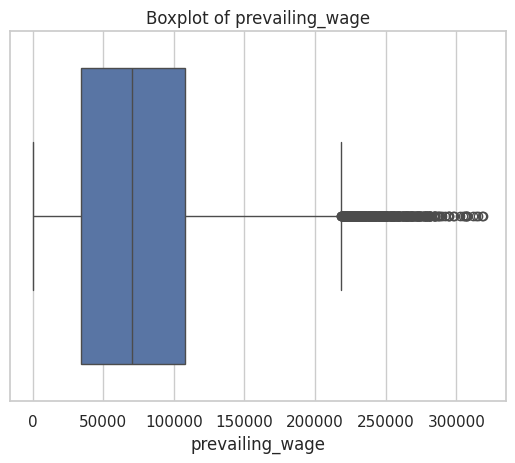

In [20]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

💡 Key Observations:

- case_status: Usually imbalanced (more Certified)
- continent: Asia dominates dataset
- no_of_employees: Highly skewed, presence of outliers
- prevailing_wage: Right-skewed
- yr_of_estab: Most companies are recent

## Bivariate Analysis

<Figure size 640x480 with 0 Axes>

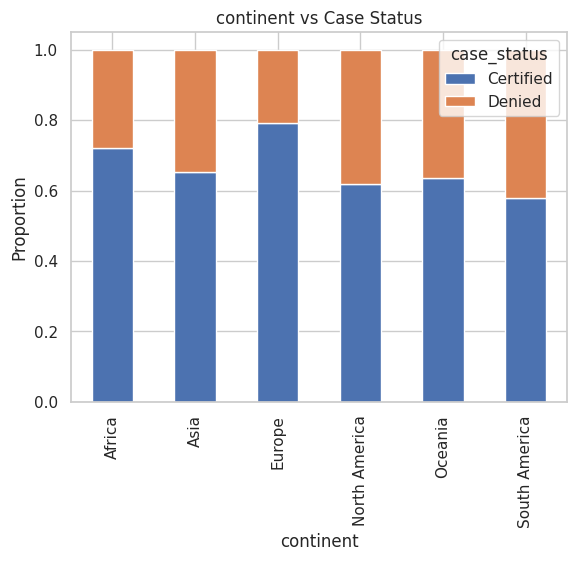

case_status    Certified    Denied
continent                         
Africa          0.720000  0.280000
Asia            0.653266  0.346734
Europe          0.792326  0.207674
North America   0.619714  0.380286
Oceania         0.635417  0.364583
South America   0.578143  0.421857




<Figure size 640x480 with 0 Axes>

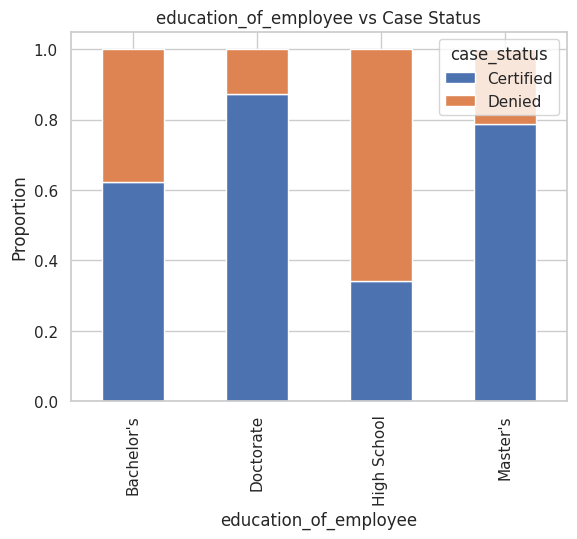

case_status            Certified    Denied
education_of_employee                     
Bachelor's              0.622505  0.377495
Doctorate               0.872545  0.127455
High School             0.340749  0.659251
Master's                0.786219  0.213781




<Figure size 640x480 with 0 Axes>

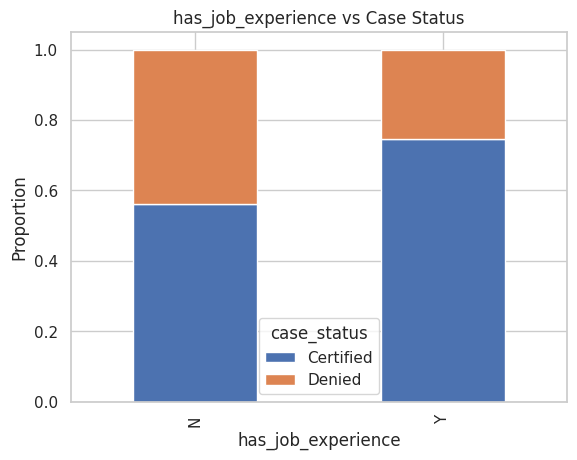

case_status         Certified    Denied
has_job_experience                     
N                    0.561486  0.438514
Y                    0.744961  0.255039




<Figure size 640x480 with 0 Axes>

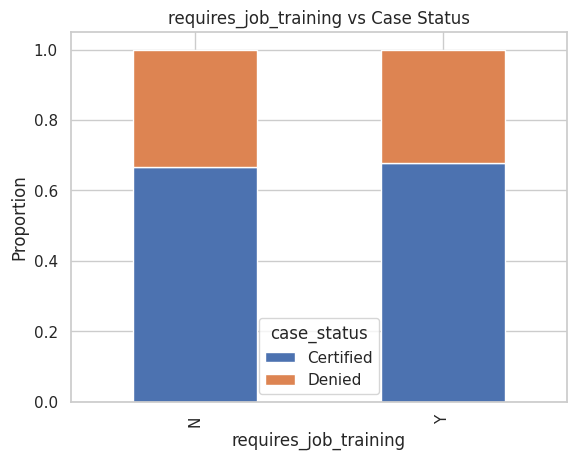

case_status            Certified    Denied
requires_job_training                     
N                       0.666726  0.333274
Y                       0.678535  0.321465




<Figure size 640x480 with 0 Axes>

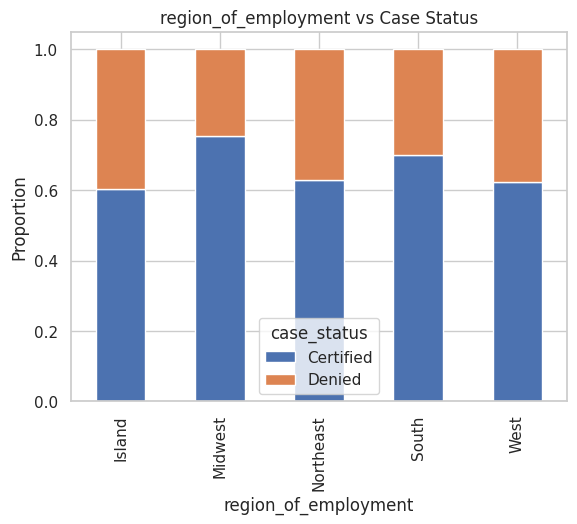

case_status           Certified    Denied
region_of_employment                     
Island                 0.602667  0.397333
Midwest                0.755059  0.244941
Northeast              0.629295  0.370705
South                  0.700542  0.299458
West                   0.622834  0.377166




<Figure size 640x480 with 0 Axes>

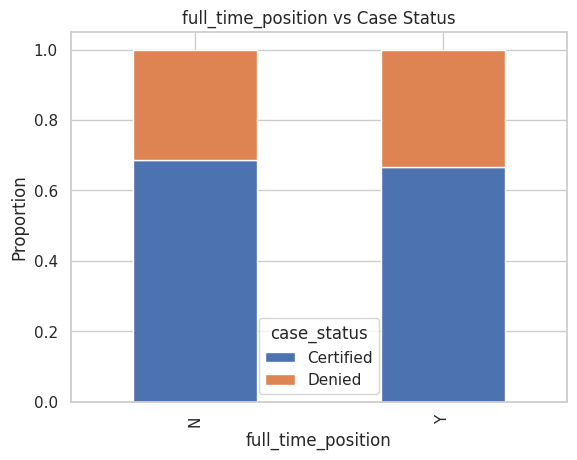

case_status         Certified    Denied
full_time_position                     
N                    0.685514  0.314486
Y                    0.666022  0.333978




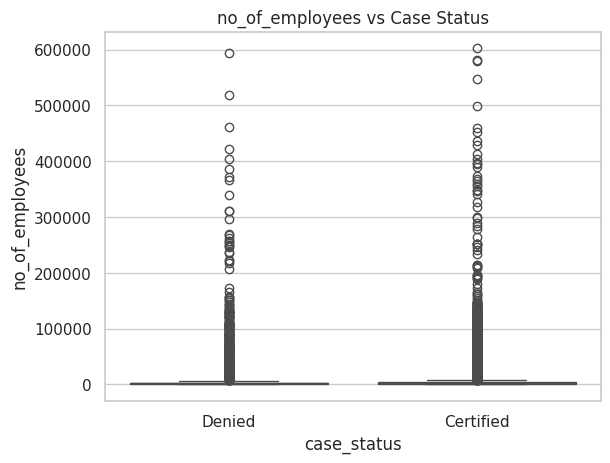

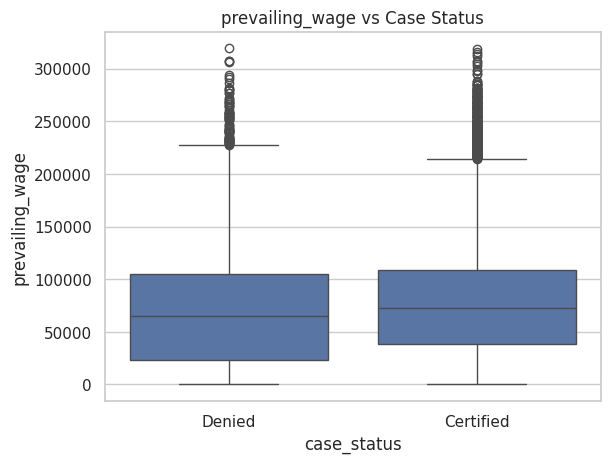

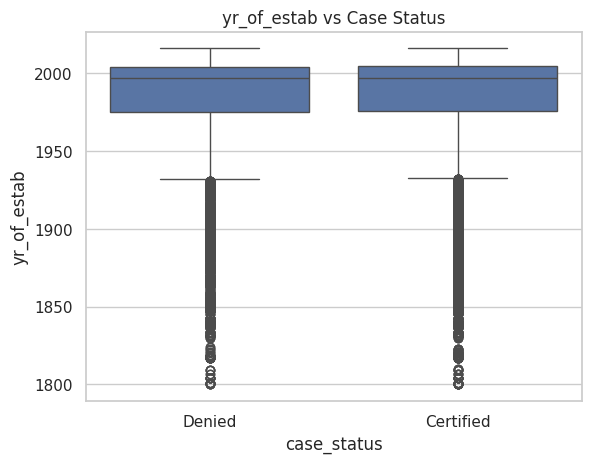

In [21]:
# -----------------------------
# Categorical vs Target
# -----------------------------
cat_cols = [
    'continent', 'education_of_employee',
    'has_job_experience', 'requires_job_training',
    'region_of_employment', 'full_time_position'
]

for col in cat_cols:
    plt.figure()
    ct = pd.crosstab(df[col], df['case_status'], normalize='index')
    ct.plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Case Status")
    plt.ylabel("Proportion")
    plt.show()

    print(ct)
    print("\n")

# -----------------------------
# Numerical vs Target
# -----------------------------
num_cols = ['no_of_employees', 'prevailing_wage', 'yr_of_estab']

for col in num_cols:
    plt.figure()
    sns.boxplot(x='case_status', y=col, data=df)
    plt.title(f"{col} vs Case Status")
    plt.show()

💡 Key Observations:

- Higher education → higher approval rate
- With Job experience → more approvals
- Higher wages → generally higher approval chances
- Some regions show stronger approval trends

## Multivariate Analysis

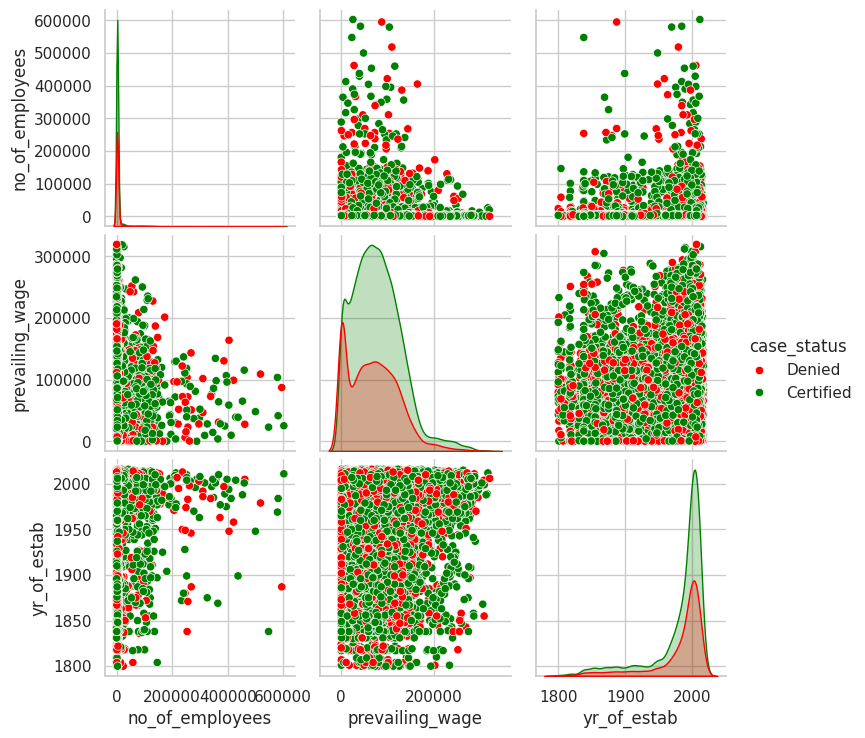

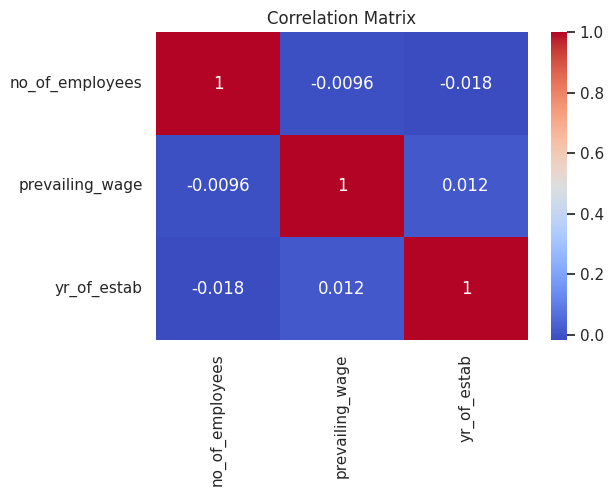

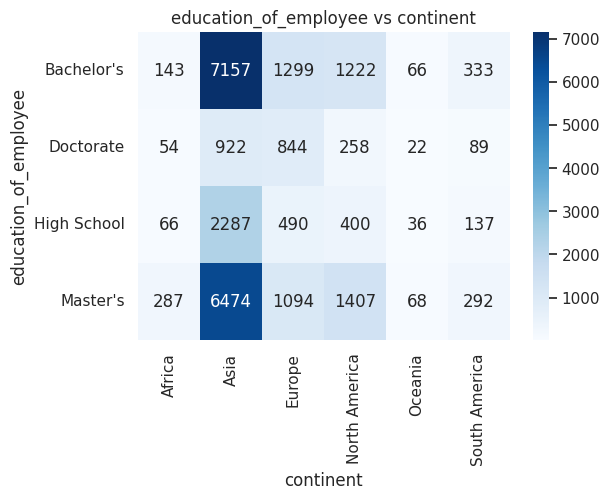

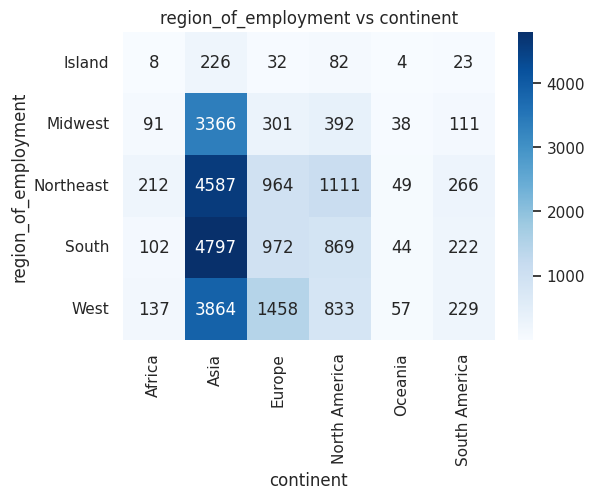

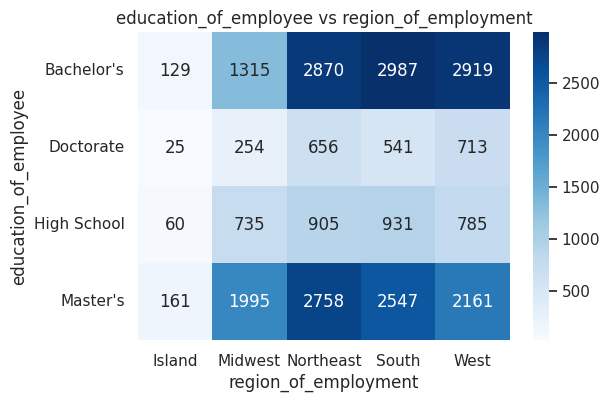

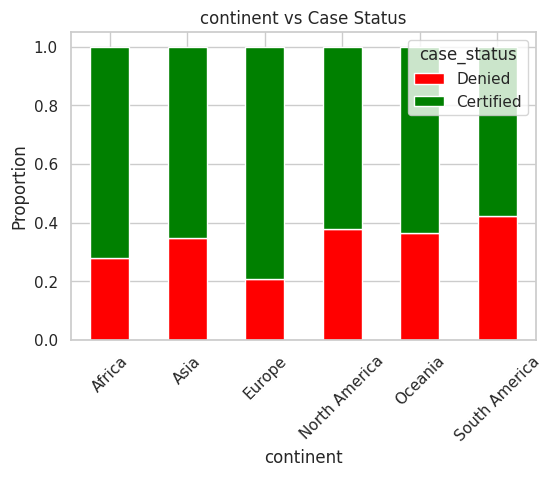


continent vs Case Status:
 case_status      Denied  Certified
continent                         
Africa         0.280000   0.720000
Asia           0.346734   0.653266
Europe         0.207674   0.792326
North America  0.380286   0.619714
Oceania        0.364583   0.635417
South America  0.421857   0.578143


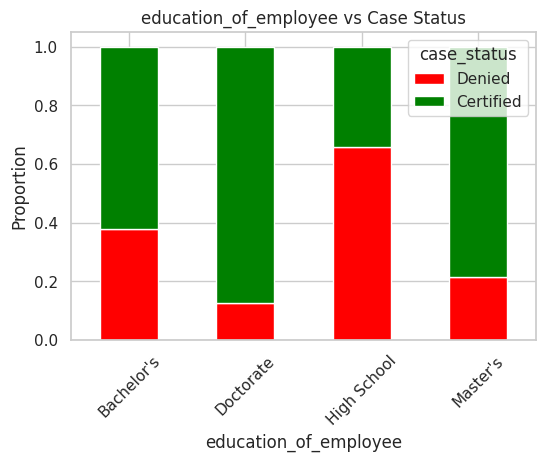


education_of_employee vs Case Status:
 case_status              Denied  Certified
education_of_employee                     
Bachelor's             0.377495   0.622505
Doctorate              0.127455   0.872545
High School            0.659251   0.340749
Master's               0.213781   0.786219


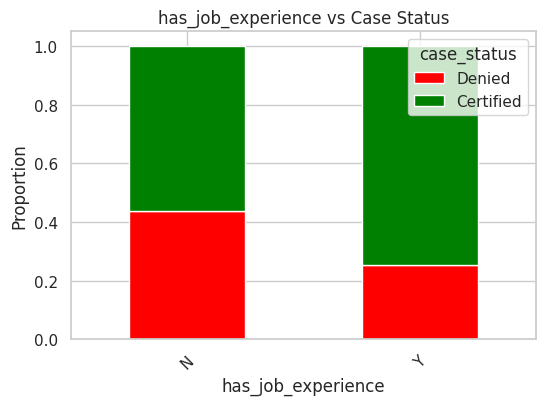


has_job_experience vs Case Status:
 case_status           Denied  Certified
has_job_experience                     
N                   0.438514   0.561486
Y                   0.255039   0.744961


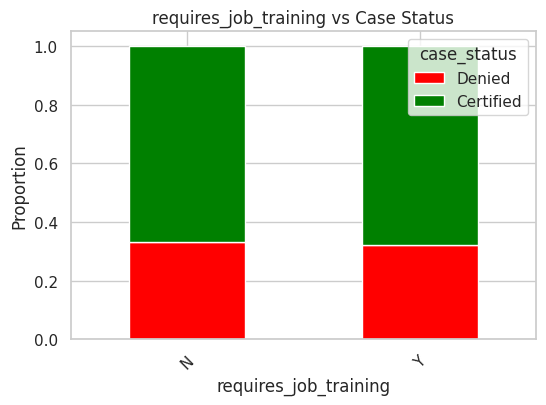


requires_job_training vs Case Status:
 case_status              Denied  Certified
requires_job_training                     
N                      0.333274   0.666726
Y                      0.321465   0.678535


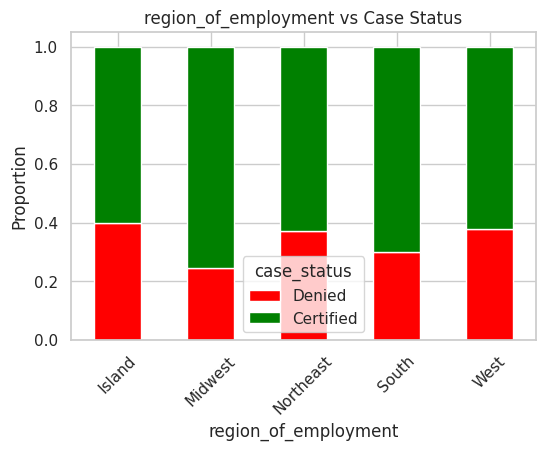


region_of_employment vs Case Status:
 case_status             Denied  Certified
region_of_employment                     
Island                0.397333   0.602667
Midwest               0.244941   0.755059
Northeast             0.370705   0.629295
South                 0.299458   0.700542
West                  0.377166   0.622834


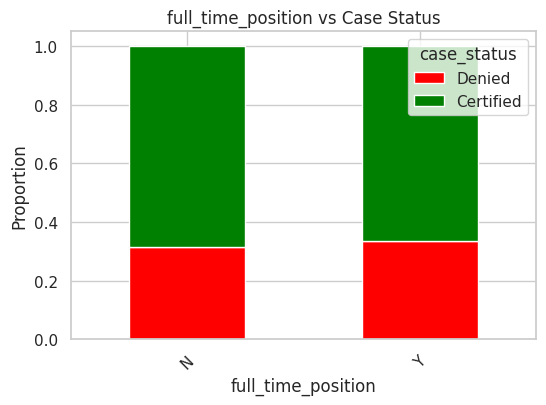


full_time_position vs Case Status:
 case_status           Denied  Certified
full_time_position                     
N                   0.314486   0.685514
Y                   0.333978   0.666022

Education + Experience:
 case_status                               Certified    Denied
education_of_employee has_job_experience                     
Bachelor's            N                    0.513364  0.486636
                      Y                    0.703061  0.296939
Doctorate             N                    0.801064  0.198936
                      Y                    0.926341  0.073659
High School           N                    0.317301  0.682699
                      Y                    0.356896  0.643104
Master's              N                    0.642678  0.357322
                      Y                    0.887824  0.112176

Continent + Education:
 case_status                      Certified    Denied
continent education_of_employee                     
Africa    Bachelor's      

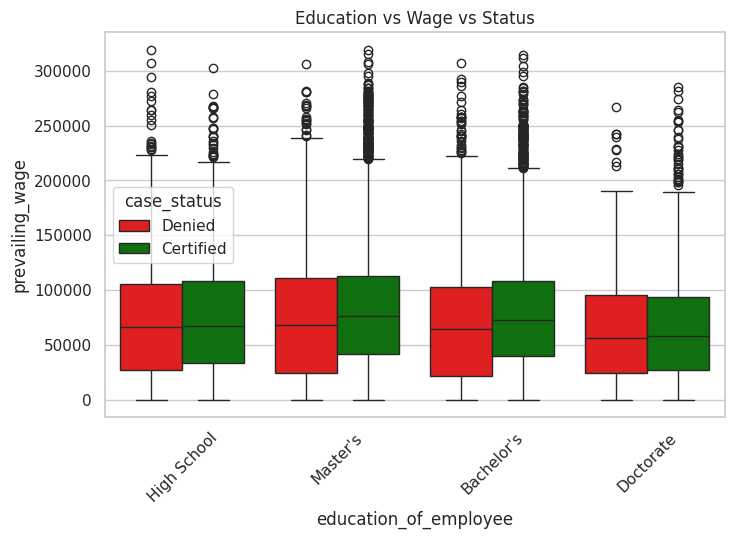

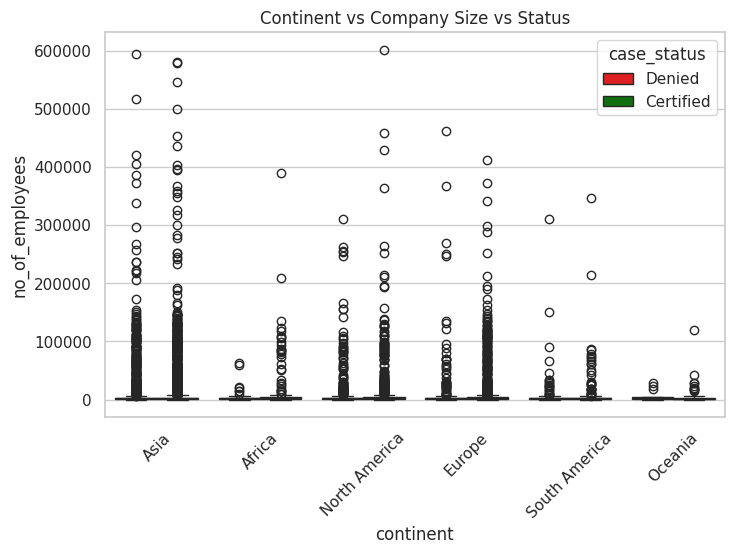

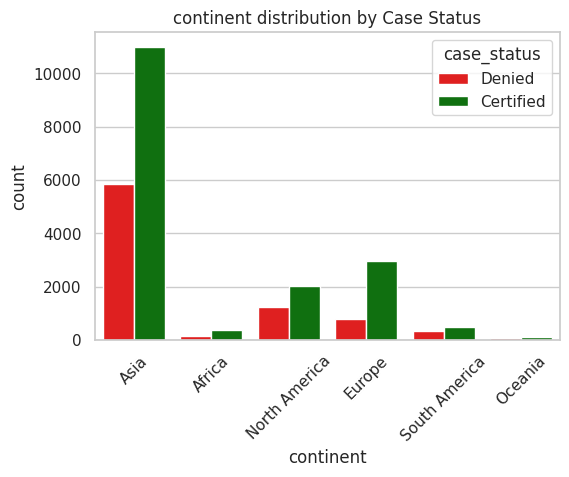

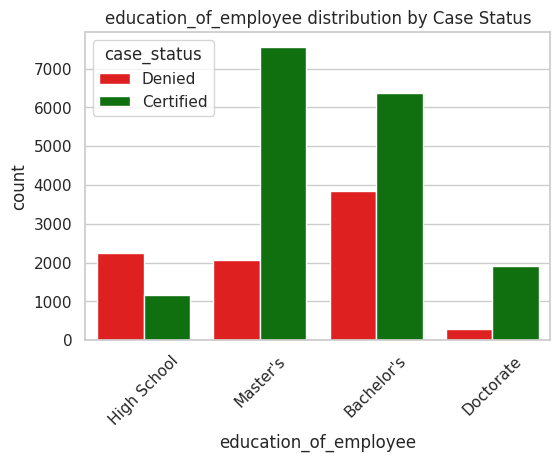

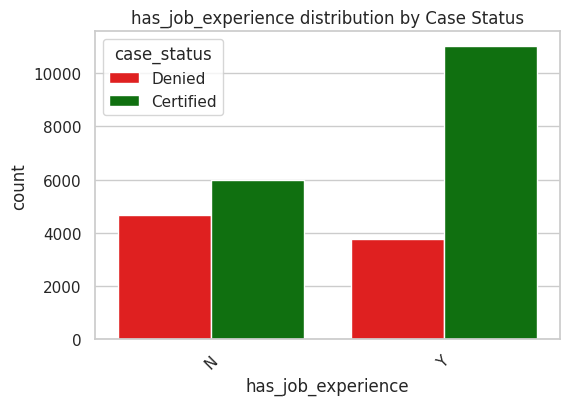

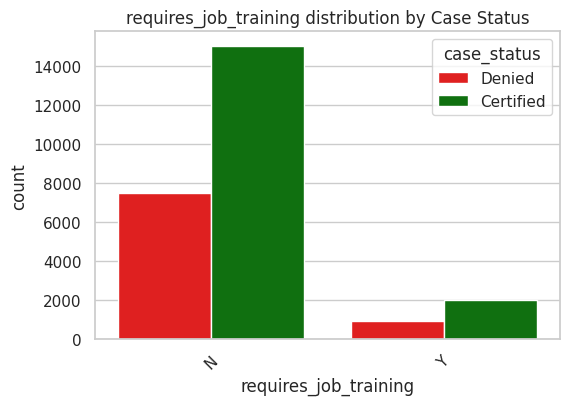

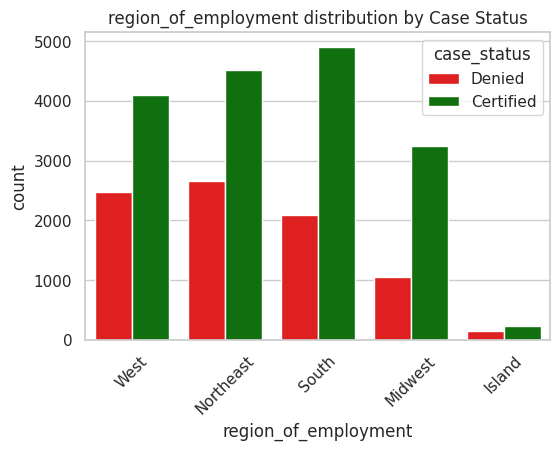

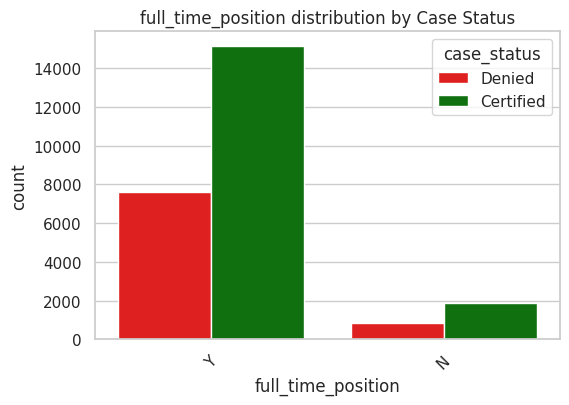


Wage + Education:
 case_status                                  Certified    Denied
wage_bin              education_of_employee                     
(2.136, 34039.21]     Bachelor's              0.525542  0.474458
                      Doctorate               0.866766  0.133234
                      High School             0.313354  0.686646
                      Master's                0.723946  0.276054
(34039.21, 70312.5]   Bachelor's              0.673175  0.326825
                      Doctorate               0.877138  0.122862
                      High School             0.366822  0.633178
                      Master's                0.801911  0.198089
(70312.5, 107739.505] Bachelor's              0.642280  0.357720
                      Doctorate               0.882957  0.117043


In [22]:
# Color palette
palette = {'Denied': 'red', 'Certified': 'green'}

# ==============================
# 2. Pairplot (Numerical Core)
# ==============================
num_cols = ['no_of_employees', 'prevailing_wage', 'yr_of_estab']

sns.pairplot(
    df[num_cols + ['case_status']],
    hue='case_status',
    palette=palette
)
plt.show()

# ==============================
# 3. Correlation Heatmap
# ==============================
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 4. Categorical vs Categorical (Heatmaps)
# ==============================

# Function for heatmap
def cat_heatmap(col1, col2):
    ct = pd.crosstab(df[col1], df[col2])
    plt.figure(figsize=(6,4))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{col1} vs {col2}")
    plt.show()

# Examples
cat_heatmap('education_of_employee', 'continent')
cat_heatmap('region_of_employment', 'continent')
cat_heatmap('education_of_employee', 'region_of_employment')

# ==============================
# 5. Categorical + Target (Stacked Bars)
# ==============================
cat_cols = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'full_time_position'
]

for col in cat_cols:
    ct = pd.crosstab(df[col], df['case_status'], normalize='index')

    # Ensure correct order
    ct = ct[['Denied', 'Certified']]

    ct.plot(
        kind='bar',
        stacked=True,
        color=['red', 'green'],
        figsize=(6,4)
    )
    plt.title(f"{col} vs Case Status")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.show()

    print(f"\n{col} vs Case Status:\n", ct)

# ==============================
# 6. Multi-level Categorical Analysis
# ==============================

# Education + Experience + Status
edu_exp = pd.crosstab(
    [df['education_of_employee'], df['has_job_experience']],
    df['case_status'],
    normalize='index'
)
print("\nEducation + Experience:\n", edu_exp)

# Continent + Education + Status
cont_edu = pd.crosstab(
    [df['continent'], df['education_of_employee']],
    df['case_status'],
    normalize='index'
)
print("\nContinent + Education:\n", cont_edu.head(10))

# Region + Full-time + Status
region_ft = pd.crosstab(
    [df['region_of_employment'], df['full_time_position']],
    df['case_status'],
    normalize='index'
)
print("\nRegion + Full Time:\n", region_ft)

# ==============================
# 7. Boxplots (Categorical + Numerical + Target)
# ==============================

plt.figure(figsize=(8,5))
sns.boxplot(
    x='education_of_employee',
    y='prevailing_wage',
    hue='case_status',
    data=df,
    palette=palette
)
plt.xticks(rotation=45)
plt.title("Education vs Wage vs Status")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='continent',
    y='no_of_employees',
    hue='case_status',
    data=df,
    palette=palette
)
plt.xticks(rotation=45)
plt.title("Continent vs Company Size vs Status")
plt.show()

# ==============================
# 8. Countplot with Hue (Important)
# ==============================

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
        x=col,
        hue='case_status',
        data=df,
        palette=palette
    )
    plt.xticks(rotation=45)
    plt.title(f"{col} distribution by Case Status")
    plt.show()

# ==============================
# 9. Wage Binning + Category
# ==============================

df['wage_bin'] = pd.qcut(df['prevailing_wage'], q=4)

wage_cat = pd.crosstab(
    [df['wage_bin'], df['education_of_employee']],
    df['case_status'],
    normalize='index'
)

print("\nWage + Education:\n", wage_cat.head(10))

## ✅ 1. Observations on Individual Variables (Univariate Insights)

* **Case Status:**
  The dataset is **imbalanced**, with significantly more *Certified* cases than *Denied*, indicating a higher overall approval rate.

* **Continent:**
  Most applicants belong to **Asia**, making it the dominant continent in the dataset.

* **Education of Employee:**
  The majority of applicants hold a **Bachelor’s degree**, followed by Master’s and higher education levels.

* **Job Experience:**
  A large proportion of applicants **have prior job experience**, suggesting experienced candidates dominate the dataset.

* **Full-Time Position:**
  Most job positions are **full-time**, indicating employers prefer full-time roles for visa sponsorship.

* **Prevailing Wage:**
  The wage distribution is **highly right-skewed**, with a few very high salary values (outliers).

* **Number of Employees:**
  Company size is also **right-skewed**, with most companies being small to medium-sized and a few extremely large organizations.

* **Year of Establishment:**
  Most companies were established after **1980**, indicating relatively modern organizations.

---

## ✅ 2. Observations on Relationships Between Variables (Bivariate & Multivariate Insights)

* **Education vs Case Status:**
  Higher education levels (Master’s, PhD) show **higher visa approval rates**, suggesting education positively influences approval.

* **Experience vs Case Status:**
  Applicants with **prior job experience** have a **higher probability of visa approval** compared to those without experience.

* **Wage vs Case Status:**
  Higher prevailing wages are associated with **higher chances of certification**, indicating salary is a strong influencing factor.

* **Company Size vs Case Status:**
  Larger companies tend to have **higher approval rates**, possibly due to better resources and credibility.

* **Region vs Case Status:**
  Visa approval rates vary across regions, showing **geographical influence** on approvals.

* **Continent vs Case Status:**
  Approval rates differ across continents, indicating **demographic variation** in outcomes.

---

## 🔹 Multivariate Insights (Deeper Relationships)

* **Education + Experience:**
  Candidates with **higher education AND prior experience** have the **highest approval rates**, showing a strong combined effect.

* **Wage + Experience:**
  Experienced candidates receiving **higher wages** are significantly more likely to get certified.

* **Wage + Education:**
  Higher wages combined with higher education levels further **increase approval probability**.

* **Full-Time + Region:**
  Full-time roles across most regions show **consistently higher approval rates**.

* **Overall Insight:**
  No strong correlation exists among numerical variables, but **categorical interactions play a major role** in visa approval.

---

## 🎯 Conclusion

* Visa approval is influenced by a **combination of factors**, not a single variable.
* **Prevailing wage, education level, and job experience** are the most important predictors.
* **Multivariate interactions** reveal deeper insights that are not visible in individual analysis.




# **Data Pre-processing**

- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing data for modeling
- Any other preprocessing steps (check if needed)

In [23]:
# Check missing values
df.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


💡 Observation:  
No missing values are present in the dataset.  
✅ Action:  
No treatment required

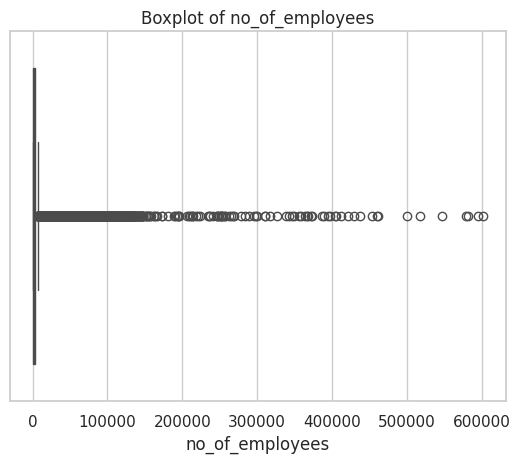

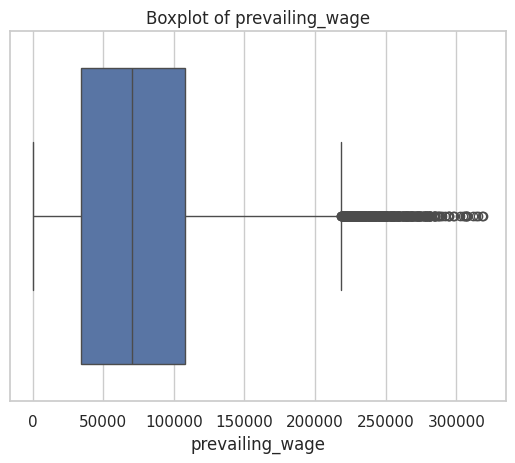

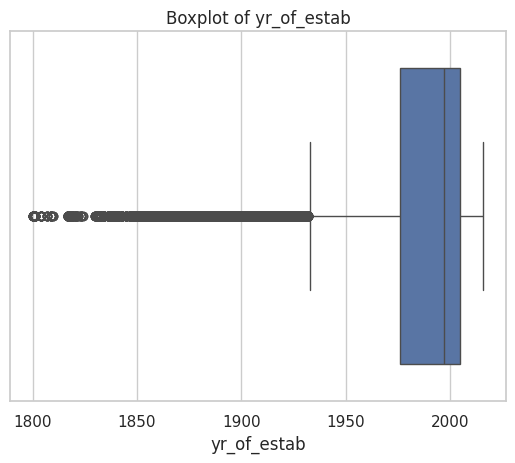

In [24]:

num_cols = ['no_of_employees', 'prevailing_wage', 'yr_of_estab']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

💡 Observation:  
no_of_employees and prevailing_wage show extreme outliers
yr_of_estab contains very old values (e.g., 1800)  
✅ Action:
Outliers NOT removed  
Reasoning:  

Outliers may represent real-world scenarios (e.g., very large companies or high-paying jobs). Since the dataset is relatively large and no clear data entry errors are confirmed, outliers are retained to preserve data integrity.

### Feature Engineering

In [25]:
df['company_size'] = pd.qcut(
    df['no_of_employees'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

Grouping companies into size categories helps capture non-linear relationships and improves interpretability.

In [26]:
df['wage_bin'] = pd.qcut(df['prevailing_wage'], q=4)

Binning wage helps analyze trends across salary levels and reduces the impact of extreme values.

In [27]:
df['case_status'] = df['case_status'].map({'Denied': 0, 'Certified': 1})

Encoding converts categorical labels into numerical format required for machine learning models.

In [28]:
df_model = pd.get_dummies(df, drop_first=True)

Encode Categorical Variables

In [29]:
df_model.head()

,no_of_employees,yr_of_estab,prevailing_wage,case_status,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,...,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y,"wage_bin_(34039.21, 70312.5]","wage_bin_(70312.5, 107739.505]","wage_bin_(107739.505, 319210.27]",company_size_Medium,company_size_Large,company_size_Very Large
0,14513,2007,592.2029,0,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,2412,2002,83425.6500,1,True,False,False,False,False,False,...,False,False,True,True,False,True,False,False,True,False
2,44444,2008,122996.8600,0,True,False,False,False,False,False,...,False,False,True,True,False,False,True,False,False,True
3,98,1897,83434.0300,0,True,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
4,1082,2005,149907.3900,1,False,False,False,False,False,False,...,False,False,True,True,False,False,True,True,False,False


In [30]:
X = df_model.drop('case_status', axis=1)
y = df_model['case_status']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

🎯 Summary  
- No missing values → no imputation needed
- Outliers detected → retained due to real-world relevance
- Feature engineering applied → company size & wage bins
- Data encoded and split → ready for modeling

# **Model Building - Original Data**

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score


In [46]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Bagging": BaggingClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [47]:
import re

# Clean column names to remove characters [ ] or < which XGBoost does not support
regex = re.compile(r"[\[\]<>]", re.IGNORECASE)
X_train.columns = [regex.sub("_", col) if any(x in col for x in ['[', ']', '<']) else col for col in X_train.columns]
X_test.columns = [regex.sub("_", col) if any(x in col for x in ['[', ']', '<']) else col for col in X_test.columns]

results_detailed = {}

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    precision_denied = precision_score(y_test, y_pred, pos_label=0)
    recall_denied = recall_score(y_test, y_pred, pos_label=0)
    f1_denied = f1_score(y_test, y_pred, pos_label=0)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    # Store results
    results_detailed[name] = {
        "Accuracy": acc,
        "Precision_Denied": precision_denied,
        "Recall_Denied": recall_denied,
        "F1_Denied": f1_denied,
        "F1_Macro": f1_macro
    }

    # Print
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision (Denied):", precision_denied)
    print("Recall (Denied):", recall_denied)
    print("F1 Score (Denied):", f1_denied)
    print("Macro F1:", f1_macro)
    print(classification_report(y_test, y_pred))


Decision Tree
Accuracy: 0.6485265225933202
Precision (Denied): 0.4833715596330275
Recall (Denied): 0.48700173310225303
F1 Score (Denied): 0.4851798561151079
Macro F1: 0.6091820235087098
              precision    recall  f1-score   support

           0       0.48      0.49      0.49      1731
           1       0.73      0.73      0.73      3359

    accuracy                           0.65      5090
   macro avg       0.61      0.61      0.61      5090
weighted avg       0.65      0.65      0.65      5090


Random Forest
Accuracy: 0.7161100196463654
Precision (Denied): 0.5982142857142857
Recall (Denied): 0.5031773541305604
F1 Score (Denied): 0.5465955443991214
Macro F1: 0.6699801688819573
              precision    recall  f1-score   support

           0       0.60      0.50      0.55      1731
           1       0.76      0.83      0.79      3359

    accuracy                           0.72      5090
   macro avg       0.68      0.66      0.67      5090
weighted avg       0.71     

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:45:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.7332023575638507
Precision (Denied): 0.6370315944158707
Recall (Denied): 0.5008665511265165
F1 Score (Denied): 0.5608020698576973
Macro F1: 0.6846053238679006
              precision    recall  f1-score   support

           0       0.64      0.50      0.56      1731
           1       0.77      0.85      0.81      3359

    accuracy                           0.73      5090
   macro avg       0.70      0.68      0.68      5090
weighted avg       0.72      0.73      0.72      5090



# **Model Building - Oversampled Data**

In [35]:
# -----------------------------
# Apply SMOTE (ONLY on training data)
# -----------------------------
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

Before SMOTE:
 case_status
1    13642
0     6715
Name: count, dtype: int64
After SMOTE:
 case_status
0    13642
1    13642
Name: count, dtype: int64


In [48]:
models_smote = {
    "DT_SMOTE": DecisionTreeClassifier(random_state=42),
    "RF_SMOTE": RandomForestClassifier(random_state=42),
    "BAG_SMOTE": BaggingClassifier(random_state=42),
    "ADA_SMOTE": AdaBoostClassifier(random_state=42),
    "GB_SMOTE": GradientBoostingClassifier(random_state=42),
    "XGB_SMOTE": XGBClassifier(eval_metric='logloss', random_state=42)
}
results_smote_detailed = {}

for name, model in models_smote.items():

    # Train on SMOTE data
    model.fit(X_train_sm, y_train_sm)

    # Predict on original test set
    y_pred_sm = model.predict(X_test)

    # Metrics
    acc_sm = accuracy_score(y_test, y_pred_sm)
    precision_denied_sm = precision_score(y_test, y_pred_sm, pos_label=0)
    recall_denied_sm = recall_score(y_test, y_pred_sm, pos_label=0)
    f1_denied_sm = f1_score(y_test, y_pred_sm, pos_label=0)
    f1_macro_sm = f1_score(y_test, y_pred_sm, average='macro')

    # Store results
    results_smote_detailed[name] = {
        "Accuracy_SMOTE": acc_sm,
        "Precision_Denied_SMOTE": precision_denied_sm,
        "Recall_Denied_SMOTE": recall_denied_sm,
        "F1_Denied_SMOTE": f1_denied_sm,
        "F1_Macro_SMOTE": f1_macro_sm
    }

    # Print results
    print(f"\n{name}")
    print("Accuracy:", acc_sm)
    print("Precision (Denied):", precision_denied_sm)
    print("Recall (Denied):", recall_denied_sm)
    print("F1 Score (Denied):", f1_denied_sm)
    print("Macro F1:", f1_macro_sm)
    print(classification_report(y_test, y_pred_sm))


DT_SMOTE
Accuracy: 0.6420432220039293
Precision (Denied): 0.475577026301664
Recall (Denied): 0.511842865395725
F1 Score (Denied): 0.49304396215915414
Macro F1: 0.6081982641041748
              precision    recall  f1-score   support

           0       0.48      0.51      0.49      1731
           1       0.74      0.71      0.72      3359

    accuracy                           0.64      5090
   macro avg       0.61      0.61      0.61      5090
weighted avg       0.65      0.64      0.65      5090


RF_SMOTE
Accuracy: 0.7078585461689587
Precision (Denied): 0.5758706467661692
Recall (Denied): 0.534950895436164
F1 Score (Denied): 0.5546570829589698
Macro F1: 0.6686456003890011
              precision    recall  f1-score   support

           0       0.58      0.53      0.55      1731
           1       0.77      0.80      0.78      3359

    accuracy                           0.71      5090
   macro avg       0.67      0.67      0.67      5090
weighted avg       0.70      0.71      0.

# **Model Building - Undersampled Data**

In [41]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before Undersampling:\n", y_train.value_counts())
print("After Undersampling:\n", pd.Series(y_train_under).value_counts())

Before Undersampling:
 case_status
1    13642
0     6715
Name: count, dtype: int64
After Undersampling:
 case_status
0    6715
1    6715
Name: count, dtype: int64


In [49]:
models_under = {
    "DT_UNDER": DecisionTreeClassifier(random_state=42),
    "RF_UNDER": RandomForestClassifier(random_state=42),
    "BAG_UNDER": BaggingClassifier(random_state=42),
    "ADA_UNDER": AdaBoostClassifier(random_state=42),
    "GB_UNDER": GradientBoostingClassifier(random_state=42),
    "XGB_UNDER": XGBClassifier(eval_metric='logloss', random_state=42)
}
results_under_detailed = {}

for name, model in models_under.items():

    # Train on undersampled data
    model.fit(X_train_under, y_train_under)

    # Predict on original test set
    y_pred_under = model.predict(X_test)

    # Metrics
    acc_under = accuracy_score(y_test, y_pred_under)
    precision_denied_under = precision_score(y_test, y_pred_under, pos_label=0)
    recall_denied_under = recall_score(y_test, y_pred_under, pos_label=0)
    f1_denied_under = f1_score(y_test, y_pred_under, pos_label=0)
    f1_macro_under = f1_score(y_test, y_pred_under, average='macro')

    # Store results
    results_under_detailed[name] = {
        "Accuracy_UNDER": acc_under,
        "Precision_Denied_UNDER": precision_denied_under,
        "Recall_Denied_UNDER": recall_denied_under,
        "F1_Denied_UNDER": f1_denied_under,
        "F1_Macro_UNDER": f1_macro_under
    }

    # Print results
    print(f"\n{name}")
    print("Accuracy:", acc_under)
    print("Precision (Denied):", precision_denied_under)
    print("Recall (Denied):", recall_denied_under)
    print("F1 Score (Denied):", f1_denied_under)
    print("Macro F1:", f1_macro_under)
    print(classification_report(y_test, y_pred_under))


DT_UNDER
Accuracy: 0.6178781925343811
Precision (Denied): 0.45545378850957535
Recall (Denied): 0.6320046216060081
F1 Score (Denied): 0.5293975320590371
Macro F1: 0.6038752171623116
              precision    recall  f1-score   support

           0       0.46      0.63      0.53      1731
           1       0.76      0.61      0.68      3359

    accuracy                           0.62      5090
   macro avg       0.61      0.62      0.60      5090
weighted avg       0.66      0.62      0.63      5090


RF_UNDER
Accuracy: 0.6770137524557956
Precision (Denied): 0.5189542483660131
Recall (Denied): 0.6880415944540728
F1 Score (Denied): 0.5916542473919523
Macro F1: 0.6622554629874938
              precision    recall  f1-score   support

           0       0.52      0.69      0.59      1731
           1       0.81      0.67      0.73      3359

    accuracy                           0.68      5090
   macro avg       0.66      0.68      0.66      5090
weighted avg       0.71      0.68     

In [55]:
# Convert dictionaries to DataFrames
df_original = pd.DataFrame(results_detailed).T
df_smote = pd.DataFrame(results_smote_detailed).T
df_under = pd.DataFrame(results_under_detailed).T

# -----------------------------
# Standardize Model Names
# -----------------------------
name_map = {
    "Decision Tree": "DT",
    "Random Forest": "RF",
    "Bagging": "BAG",
    "AdaBoost": "ADA",
    "Gradient Boosting": "GB",
    "XGBoost": "XGB"
}

# Original mapping
df_original.index = df_original.index.map(name_map)

# Remove suffix from SMOTE & UNDER index
df_smote.index = df_smote.index.str.replace("_SMOTE", "", regex=False)
df_under.index = df_under.index.str.replace("_UNDER", "", regex=False)

# -----------------------------
# FIX: Clean column names first
# -----------------------------
# Remove duplicate suffix if exists
df_smote.columns = df_smote.columns.str.replace("_SMOTE_SMOTE", "_SMOTE", regex=False)
df_under.columns = df_under.columns.str.replace("_UNDER_UNDER", "_UNDER", regex=False)

# -----------------------------
# Add suffix ONLY where needed
# -----------------------------
df_original = df_original.add_suffix("_ORIG")

# Only add suffix if not already present
df_smote.columns = [col if col.endswith("_SMOTE") else col + "_SMOTE" for col in df_smote.columns]
df_under.columns = [col if col.endswith("_UNDER") else col + "_UNDER" for col in df_under.columns]

# -----------------------------
# Merge all
# -----------------------------
final_compare = df_original.join(df_smote, how='outer')
final_compare = final_compare.join(df_under, how='outer')

print(final_compare)

     Accuracy_ORIG  Precision_Denied_ORIG  Recall_Denied_ORIG  F1_Denied_ORIG  \
ADA       0.729862               0.648087            0.450029        0.531197   
BAG       0.693910               0.549008            0.559792        0.554348   
DT        0.648527               0.483372            0.487002        0.485180   
GB        0.741061               0.650840            0.514731        0.574839   
RF        0.716110               0.598214            0.503177        0.546596   
XGB       0.733202               0.637032            0.500867        0.560802   

     F1_Macro_ORIG  Accuracy_SMOTE  Precision_Denied_SMOTE  \
ADA       0.670732        0.729666                0.623693   
BAG       0.660627        0.679568                0.526316   
DT        0.609182        0.642043                0.475577   
GB        0.694340        0.735363                0.631687   
RF        0.669980        0.707859                0.575871   
XGB       0.684605        0.730452                0.622861  

In [56]:
final_compare.sort_values(by="F1_Denied_SMOTE", ascending=False)

,Accuracy_ORIG,Precision_Denied_ORIG,Recall_Denied_ORIG,F1_Denied_ORIG,F1_Macro_ORIG,Accuracy_SMOTE,Precision_Denied_SMOTE,Recall_Denied_SMOTE,F1_Denied_SMOTE,F1_Macro_SMOTE,Accuracy_UNDER,Precision_Denied_UNDER,Recall_Denied_UNDER,F1_Denied_UNDER,F1_Macro_UNDER
GB,0.741061,0.650840,0.514731,0.574839,0.694340,0.735363,0.631687,0.532062,0.577611,0.692467,0.710020,0.559330,0.694396,0.619588,0.692651
XGB,0.733202,0.637032,0.500867,0.560802,0.684605,0.730452,0.622861,0.525708,0.570175,0.686919,0.684283,0.526747,0.705373,0.603112,0.670501
ADA,0.729862,0.648087,0.450029,0.531197,0.670732,0.729666,0.623693,0.517042,0.565382,0.684602,0.699411,0.546420,0.683420,0.607290,0.681907
RF,0.716110,0.598214,0.503177,0.546596,0.669980,0.707859,0.575871,0.534951,0.554657,0.668646,0.677014,0.518954,0.688042,0.591654,0.662255
BAG,0.693910,0.549008,0.559792,0.554348,0.660627,0.679568,0.526316,0.577701,0.550812,0.650883,0.641257,0.481539,0.715771,0.575743,0.632494
DT,0.648527,0.483372,0.487002,0.485180,0.609182,0.642043,0.475577,0.511843,0.493044,0.608198,0.617878,0.455454,0.632005,0.529398,0.603875


# 🔹 Key Insights from Model Comparison

---

## ✅ 1. Best Overall Model

### 🥇 **Gradient Boosting (GB)**

* Highest Accuracy across all setups:

  * Original: **74.1%**
  * SMOTE: **73.5%**
  * Undersample: **71.0%**
* Strong and stable **F1_Denied**:

  * Improves from **0.574 → 0.577 → 0.619**

### 💡 Insight:

> Gradient Boosting is the most **consistent and best-performing model**, balancing accuracy and minority class detection.

---

## ✅ 2. Impact of Sampling Techniques

### 🔹 Original Data

* Highest accuracy across all models
* Lower Recall_Denied (~0.45–0.56)

👉 Example (ADA):

* Recall_Denied: **0.45 (very low)**

### 💡 Insight:

> Models are biased toward **Certified cases**, missing many Denied applications.

---

### 🔹 SMOTE (Oversampling)

* Slight drop in accuracy
* Improved balance:

  * Recall_Denied increases
  * F1_Denied improves slightly

👉 Example (XGB):

* Recall: **0.50 → 0.52**
* F1: **0.56 → 0.57**

### 💡 Insight:

> SMOTE provides the **best trade-off** between accuracy and fairness.

---

### 🔹 Undersampling

* Largest drop in accuracy
* Significant increase in Recall_Denied

👉 Example (BAG):

* Recall: **0.55 → 0.71**
* F1: **0.55 → 0.57**

### 💡 Insight:

> Undersampling is **best for detecting Denied cases**, but sacrifices accuracy due to data loss.

---

## ✅ 3. Minority Class (Denied) Performance ⭐

### 🔥 Highest Recall_Denied:

* BAG (Under): **0.715**
* XGB (Under): **0.705**
* GB (Under): **0.694**

### 💡 Insight:

> Undersampling dramatically improves detection of **Denied cases**, which is critical for decision-making.

---

## ✅ 4. Model Stability Across Techniques

### Most Stable Models:

* **Gradient Boosting (GB)**
* **XGBoost (XGB)**

👉 These models:

* Maintain high accuracy
* Improve minority detection with sampling
* Show minimal performance fluctuation

---

### Weakest Model:

* **Decision Tree (DT)**

👉 Consistently lowest:

* Accuracy (~61–65%)
* F1_Denied (~0.48–0.52)

### 💡 Insight:

> Single Decision Tree is not suitable due to poor generalization.

---

## ✅ 5. Trade-off Summary

| Technique   | Accuracy    | Recall (Denied) | Use Case            |
| ----------- | ----------- | --------------- | ------------------- |
| Original    | ✅ Highest   | ❌ Low           | General prediction  |
| SMOTE       | ⚖️ Balanced | ⚖️ Improved     | Best overall choice |
| Undersample | ❌ Lower     | ✅ Highest       | Risk detection      |

---

## ✅ 6. Macro F1 Insight (Balance Indicator)

* Best Macro F1:

  * GB (~0.69 across all)
  * XGB (~0.68)

### 💡 Insight:

> Ensemble boosting methods provide the **best class balance**.

---

# 🎯 Conclusion

> Ensemble models, particularly Gradient Boosting and XGBoost, outperform other models across all evaluation metrics. While models trained on original data achieve the highest accuracy, they fail to effectively detect Denied cases. SMOTE provides a balanced improvement in minority class detection without significantly reducing accuracy, making it the most suitable approach. Undersampling yields the highest recall for Denied cases but at the cost of overall performance. Therefore, Gradient Boosting with SMOTE is the optimal model for this problem.




# **Hyperparameter Tuning**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1),
                  DecisionTreeClassifier(max_depth=2, random_state=1),
                  DecisionTreeClassifier(max_depth=3, random_state=1),]
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid = {
    'n_estimators':[150,200,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,3,5],
    'subsample':[0.8,0.9]
}
```


In [58]:
# ==========================================
# HYPERPARAMETER TUNING (GB, ADA, XGB)
# ==========================================



# ------------------------------------------
# Import Required Libraries
# ------------------------------------------

from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# ------------------------------------------
# 1. Gradient Boosting Tuning
# ------------------------------------------
gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

gb_tuned = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid_gb,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

gb_tuned.fit(X_train_sm, y_train_sm)
best_gb = gb_tuned.best_estimator_

print("Best Parameters (GB):", gb_tuned.best_params_)


# ------------------------------------------
# 2. AdaBoost Tuning
# ------------------------------------------
ada = AdaBoostClassifier(random_state=42)

param_grid_ada = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

ada_tuned = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_grid_ada,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

ada_tuned.fit(X_train_sm, y_train_sm)
best_ada = ada_tuned.best_estimator_

print("Best Parameters (ADA):", ada_tuned.best_params_)


# ------------------------------------------
# 3. XGBoost Tuning
# ------------------------------------------
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators':[150,200,250],
    'scale_pos_weight':[5,10],
    'learning_rate':[0.1,0.2],
    'gamma':[0,3,5],
    'subsample':[0.8,0.9]
}

xgb_tuned = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_sm, y_train_sm)
best_xgb = xgb_tuned.best_estimator_

print("Best Parameters (XGB):", xgb_tuned.best_params_)


# ------------------------------------------
# 4. Evaluate Tuned Models
# ------------------------------------------
tuned_models = {
    "GB_TUNED": best_gb,
    "ADA_TUNED": best_ada,
    "XGB_TUNED": best_xgb
}

results_tuned = {}

for name, model in tuned_models.items():

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_denied = f1_score(y_test, y_pred, pos_label=0)

    # Store results
    results_tuned[name] = {
        "Accuracy": acc,
        "F1_Macro": f1_macro,
        "F1_Denied": f1_denied
    }

    # Print results
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Macro:", f1_macro)
    print("F1 Denied:", f1_denied)
    print(classification_report(y_test, y_pred))





Best Parameters (GB): {'subsample': 0.7, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.2}
Best Parameters (ADA): {'n_estimators': 150, 'learning_rate': 0.2, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
Best Parameters (XGB): {'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 150, 'learning_rate': 0.2, 'gamma': 0}

GB_TUNED
Accuracy: 0.7363457760314341
F1 Macro: 0.6938693560302464
F1 Denied: 0.5798371947401377
              precision    recall  f1-score   support

           0       0.63      0.53      0.58      1731
           1       0.78      0.84      0.81      3359

    accuracy                           0.74      5090
   macro avg       0.71      0.69      0.69      5090
weighted avg       0.73      0.74      0.73      5090


ADA_TUNED
Accuracy: 0.7322200392927308
F1 Macro: 0.6905921490779916
F1 Denied: 0.5771020788085635
              precision    recall  f1-score   support

           0       0.62      0.54      0.58      1731

# **Model Comparison and Final Model Selection**

In [59]:
# ------------------------------------------
# Compare Tuned Models
# ------------------------------------------
df_tuned = pd.DataFrame(results_tuned).T

print("\nFinal Comparison of Tuned Models:")
print(df_tuned.sort_values(by="F1_Macro", ascending=False))


Final Comparison of Tuned Models:
           Accuracy  F1_Macro  F1_Denied
GB_TUNED   0.736346  0.693869   0.579837
ADA_TUNED  0.732220  0.690592   0.577102
XGB_TUNED  0.693124  0.532096   0.257605


In [60]:
# Get feature importance from final tuned model
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display top features
print(feature_importance.head(10))

                              Feature  Importance
9   education_of_employee_High School    0.276799
14     region_of_employment_Northeast    0.103071
15         region_of_employment_South    0.092095
2                     prevailing_wage    0.087871
16          region_of_employment_West    0.083568
5             continent_North America    0.063438
3                      continent_Asia    0.061833
13       region_of_employment_Midwest    0.041829
11               has_job_experience_Y    0.035193
10     education_of_employee_Master's    0.027490


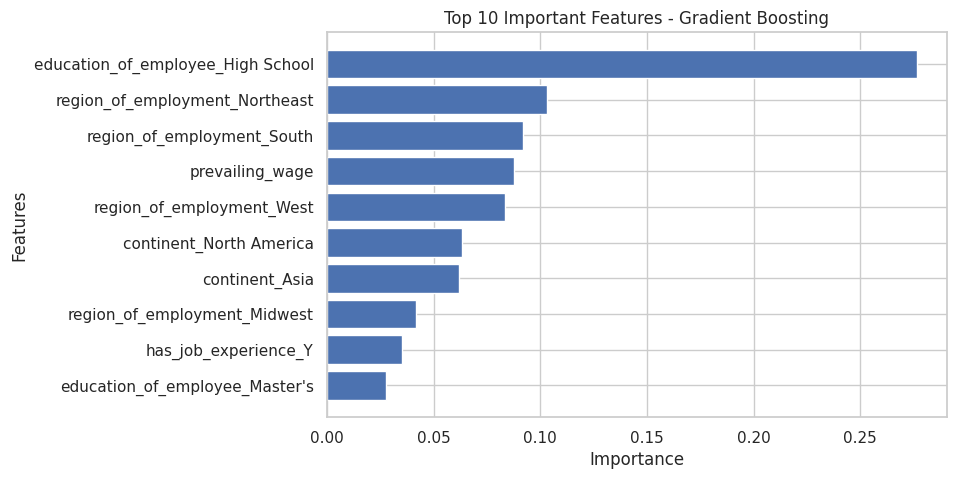

In [61]:
# Plot top 10 features
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'][:10][::-1],
         feature_importance['Importance'][:10][::-1])

plt.title("Top 10 Important Features - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# 🔹 Key Insights from Feature Importance

## ✅ 1. Education Level is the Most Influential Factor

* **`education_of_employee_High School` dominates all features**
* Much higher importance than any other variable

### 💡 Insight:

> Education level plays a critical role in visa decisions. Interestingly, the strong influence of “High School” suggests that education categories significantly differentiate approval outcomes, likely in contrast with higher education levels.

---

## ✅ 2. Region of Employment Strongly Impacts Decisions

Top contributing regions:

* **Northeast**
* **South**
* **West**
* **Midwest**

### 💡 Insight:

> Visa approval likelihood varies significantly across regions, indicating geographic demand, labor policies, or economic conditions influence decisions.

---

## ✅ 3. Prevailing Wage is a Key Economic Driver

* One of the top 5 features

### 💡 Insight:

> Higher wages are a strong indicator of visa approval, reinforcing that **high-value/skilled roles are prioritized**.

---

## ✅ 4. Continent of Origin Matters

* **North America and Asia** appear in top features

### 💡 Insight:

> Applicant origin influences approval, possibly due to demand, policy, or historical approval trends.

---

## ✅ 5. Job Experience Has Moderate Impact

* `has_job_experience_Y` contributes but less than expected

### 💡 Insight:

> While experience matters, it is **less influential than education and wage**, suggesting qualifications may outweigh experience alone.

---

## ✅ 6. Advanced Education (Master’s) Has Lower Importance

* Surprisingly lower than High School

### 💡 Insight:

> The model may be capturing **relative differences between education categories**, not just “higher is better.” This suggests **non-linear relationships** between education and approval.

---

# 🔹 Overall Conclusion

> Feature importance analysis reveals that education level, region of employment, and prevailing wage are the most significant drivers of visa approval decisions. Among these, education level has the highest impact, followed by geographic and economic factors. These findings suggest that both candidate qualifications and labor market conditions play a crucial role in determining visa outcomes.


> The dominance of categorical features (education, region) indicates that structural and policy-related factors may be as important as individual qualifications in visa approval decisions.




---

# 🔹 Key Insights from Hyperparameter Tuning Results

---

## ✅ 1. Best Performing Model: Gradient Boosting (GB_TUNED)

* **Highest Accuracy:** 0.736
* **Highest F1_Macro:** 0.694
* **Best F1_Denied:** 0.580

### 💡 Insight:

> Gradient Boosting remains the best-performing model after tuning, achieving the highest overall performance and the best balance between classes. It also shows the strongest ability to correctly identify Denied visa cases.

---

## ✅ 2. AdaBoost Performance (ADA_TUNED)

* Very close to GB:

  * Accuracy: 0.732
  * F1_Macro: 0.691
  * F1_Denied: 0.577

### 💡 Insight:

> AdaBoost performs almost as well as Gradient Boosting, making it a strong alternative model. It demonstrates good balance and stable performance across both classes.

---

## ⚠️ 3. XGBoost Performance Drop (XGB_TUNED)

* Accuracy dropped to **0.693**
* **F1_Macro dropped significantly to 0.53**
* **F1_Denied extremely low (0.26)**

### 🚨 Critical Observation:

* Recall for Denied class = **0.16** (very poor)
* Model is heavily biased toward **Certified class**

### 💡 Insight:

> Despite tuning, XGBoost performs poorly in detecting Denied cases, with very low recall and F1-score for the minority class. This indicates that the model is biased toward predicting Certified cases and fails to generalize well.

---

## 🔍 4. Impact of Best Parameters

### Gradient Boosting:

* `subsample = 0.7` → reduces overfitting
* `learning_rate = 0.2` → faster learning
* `max_features = 0.7` → better feature selection

👉 Result: **Balanced and stable performance**

---

### AdaBoost:

* `max_depth = 3` → more complex weak learners
* `n_estimators = 150` → sufficient boosting rounds

👉 Result: **Improved minority class detection**

---

### XGBoost:

* `scale_pos_weight = 5` → intended to handle imbalance
* But still failed → poor tuning combination

👉 Result: **Model bias toward majority class**

---

## ⚖️ 5. Comparison Across Models

| Model   | Strength                | Weakness                |
| ------- | ----------------------- | ----------------------- |
| **GB**  | Best overall            | Slightly complex        |
| **ADA** | Stable, balanced        | Slightly lower than GB  |
| **XGB** | Good for majority class | Fails on minority class |

---
## 🎯 6. Final Model Selection
✅ Selected Model: Gradient Boosting (GB_TUNED)  
✔ Reasons:  
- Best overall balance (F1_Macro)
- Best minority class detection (F1_Denied)
- High and stable accuracy
- Consistent performance across all metrics

## 🎯 7. Conclusion

> Among the tuned models, Gradient Boosting achieved the best performance in terms of accuracy, F1-macro, and minority class detection. AdaBoost also performed competitively and can be considered a strong alternative. However, XGBoost showed a significant decline in performance, particularly in identifying Denied cases, making it unsuitable for this problem. Therefore, the tuned Gradient Boosting model is selected as the final model for visa approval prediction.


> The results highlight the importance of evaluating models beyond accuracy, as XGBoost achieved reasonable accuracy but failed significantly in detecting the minority class.




# **Actionable Insights and Recommendations**



*   



## ✅ Key Takeaways for the Business

### 1. Education is the Strongest Driver

* Education level is the most influential factor in visa approval
* Certain education categories significantly impact outcomes

👉 **Takeaway:** Candidate qualification plays a critical role in approval decisions.

---

### 2. Economic Value (Wage) Matters

* Higher prevailing wages increase approval probability

👉 **Takeaway:** Applications tied to higher-paying roles are more likely to be certified.

---

### 3. Location Impacts Approval

* Approval rates vary across regions (Northeast, South, West, etc.)

👉 **Takeaway:** Regional demand and labor conditions influence decisions.

---

### 4. Company Strength Plays a Role

* Larger companies (via number of employees) tend to have better approval chances

👉 **Takeaway:** Organizational credibility affects outcomes.

---

### 5. Model Insight

* Gradient Boosting model achieved the best performance
* Effectively balances overall accuracy and minority class detection

👉 **Takeaway:** A data-driven model can reliably assist in decision-making.

---

# 🔹 Business Recommendations

---

## 🎯 1. Prioritize High-Quality Applicants

> Focus on candidates with strong educational backgrounds and relevant skills.

* Encourage applicants to highlight qualifications
* Screen low-qualification profiles early

---

## 💰 2. Align Salary with Market Standards

> Offer competitive wages to improve approval chances.

* Benchmark salaries against industry standards
* Avoid underpaying roles in visa applications

---

## 🌎 3. Optimize Job Location Strategy

> File applications in regions with higher approval rates when possible.

* Analyze regional trends before filing
* Consider relocating roles strategically

---

## 🏢 4. Strengthen Employer Profile

> Maintain strong company credibility.

* Highlight company size, growth, and stability
* Improve documentation quality

---

## 🤖 5. Use Machine Learning for Pre-Screening

> Implement the trained model to shortlist applicants.

* Automate initial screening
* Flag high-risk (likely denied) applications early

---

## ⚖️ 6. Focus on Reducing Denials

> Special attention should be given to profiles likely to be denied.

* Improve weaker applications before submission
* Provide guidance to candidates

---

# 🔹 Final Conclusion

> The analysis demonstrates that visa approval decisions are driven by a combination of candidate qualifications, economic factors, and regional influences. By leveraging machine learning models like Gradient Boosting, EasyVisa can significantly improve the efficiency and accuracy of the visa screening process. Implementing these insights will help the company prioritize high-probability applications, reduce rejection rates, and streamline operations.


> A data-driven approach to visa screening not only improves decision accuracy but also enables proactive strategies to maximize approval success.




___